In [1]:
!git clone https://github.com/thunderbolt190/teleport-mcmc.git
%cd teleport-mcmc
!pip install -e ".[dev]" -q

import time
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
!pip install emcee
import emcee

from teleport.kernels.teleporting import teleporting_walkers_jax

Cloning into 'teleport-mcmc'...
remote: Enumerating objects: 776, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 776 (delta 31), reused 19 (delta 19), pack-reused 731 (from 2)
Receiving objects: 100% (776/776), 862.63 KiB | 6.03 MiB/s, done.
Resolving deltas: 100% (447/447), done.
/content/teleport-mcmc
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 108.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 20.0 MB/s eta 0:00:00
  Building editable for teleport-mcmc (pyproject.toml) ...

In [2]:
key = jax.random.PRNGKey(42)
keys = jax.random.split(key, 3)

n_pts = 40
x = jax.random.normal(keys[0], shape = (n_pts, 1))
sigma = jnp.where(jnp.abs(x) < 1.5, 0.125, 1.25)
delta = sigma * jax.random.normal(keys[1], shape = (n_pts, 1))

def fn(x):
  return 0.3 + 0.4 * x + 0.5 * jnp.sin(2.7 * x) + 1.1 / (1 + x ** 2)

y = fn(x) + delta

print(x.shape)
print(y.shape)


(40, 1)
(40, 1)


In [3]:
def log_prob_student_t(state):
  alpha = state[0]
  rho   = state[1]
  sigma = state[2]
  w     = state[3:]

  valid = (alpha > 0) & (rho > 0) & (sigma > 0)

  x_flat = x.ravel()
  mid = (x_flat[:, None] - x_flat[None, :]) ** 2
  K = alpha ** 2 * jnp.exp(- mid / rho ** 2)

  L = jnp.linalg.cholesky(K + 1e-6 * jnp.eye(n_pts))
  eps = y.ravel() + L @ w.ravel()

  likelihood = - n_pts * jnp.log(sigma) - 1.5 * jnp.sum(jnp.log(1 + eps ** 2 / (2 * sigma ** 2)))
  log_w = -0.5 * jnp.sum(w**2)
  log_prior = - jnp.log(1 + (alpha/3)**2) - jnp.log(1 + (rho/3)**2) - jnp.log(1 + (sigma/3)**2)

  return jnp.where(valid, log_w + log_prior + likelihood, -jnp.inf)

In [4]:
state = jnp.concatenate([jnp.array([1.0, 1.0, 0.5]),
                         jax.random.normal(jax.random.PRNGKey(0), (n_pts,))])
print(log_prob_student_t(state))

print(log_prob_student_t(state.at[0].set(-1.0)))
print(log_prob_student_t(state.at[2].set(-0.1)))

states = jnp.stack([state, state.at[1].set(1.5)])
print(jax.vmap(log_prob_student_t)(states))

print(jax.jit(log_prob_student_t)(state))

-66.41455180242721
-inf
-inf
[-66.4145518  -65.32234979]
-66.41455180242723


In [5]:
from teleport.kernels.teleporting import teleporting_walkers_jax

key = jax.random.PRNGKey(0)
n_walkers = 8
m = n_pts
dim = 3 + m

center = jnp.concatenate([jnp.array([1.0, 1.0, 0.5]), jnp.zeros(m)])
init = center + 0.05 * jax.random.normal(key, (n_walkers, dim))
init = init.at[:, 0:3].set(jnp.abs(init[:, 0:3]))

step_size = 0.05
n_steps = 100

final, chain, accepts, teleports = teleporting_walkers_jax(
    init, log_prob_student_t, step_size, n_steps, key
)

print(final.shape)
print(chain.shape)
print(float(jnp.mean(accepts)), float(jnp.mean(teleports)))
print(final[0, :3])

(8, 43)
(100, 8, 43)
0.5399999618530273 0.009999999776482582
[1.07896442 0.98598016 0.57288079]


In [6]:
def mh_update_w(state, key, step_w = jnp.sqrt(0.001)):
  w = state[3:]
  key1, key2 = jax.random.split(key)
  w_prop = w + step_w * jax.random.normal(key1, w.shape)
  state_prop = state.at[3:].set(w_prop)
  log_alpha = log_prob_student_t(state_prop) -  log_prob_student_t(state)
  accept = jnp.log(jax.random.uniform(key2)) < log_alpha
  new_state = jnp.where(accept, state_prop, state)
  return new_state, accept

In [7]:
state = jnp.concatenate([jnp.array([1.0, 1.0, 0.5]),
                         jax.random.normal(jax.random.PRNGKey(1), (m,))])
new_state, acc = mh_update_w(state, jax.random.PRNGKey(2))
print(new_state.shape)
print(new_state[:3])
print(jnp.allclose(new_state[:3], state[:3]))
print(acc)

(43,)
[1.  1.  0.5]
True
False


In [8]:
accs = []
s = state
key = jax.random.PRNGKey(10)
for i in range(20):
    key, sub = jax.random.split(key)
    s, a = mh_update_w(s, sub)
    accs.append(bool(a))
print(accs)
print(sum(accs) / len(accs))

[True, True, False, False, True, True, True, True, False, True, True, True, True, True, True, True, False, True, True, True]
0.8


In [9]:
def compute_log_weights_2(walkers, log_probs, z, sigma):
  N = walkers.shape[0]
  walkers = walkers[:, :3]
  z = z[:3]
  diff = walkers[:, None, :] - walkers[None, :, :]
  M = -0.5 * jnp.sum(diff ** 2, axis = -1) / sigma ** 2
  M = M.at[jnp.arange(N), jnp.arange(N)].set(-jnp.inf)
  diff_z = walkers - z[None, :]
  log_q_z = -0.5 * jnp.sum(diff_z ** 2, axis = -1) / sigma ** 2
  all_log_q = jnp.concatenate([log_q_z[:, None], M], axis = 1)
  log_w = jax.scipy.special.logsumexp(all_log_q, axis = 1) - log_probs
  return log_w

In [10]:
N, m = 8, n_pts
key = jax.random.PRNGKey(0)
w_part = jax.random.normal(key, (N, m))
theta = jnp.abs(jax.random.normal(key, (N, 3))) + 0.1
walkers = jnp.concatenate([theta, w_part], axis=1)
z = walkers[0]
log_probs = jax.vmap(log_prob_student_t)(walkers)
w = compute_log_weights_2(walkers, log_probs, z, 0.05)
print(w.shape)
print(log_probs)
print(w)
print(jnp.all(jnp.isfinite(w) | jnp.isneginf(w)))

(8,)
[ -58.17640818  -60.44392336 -171.76588047  -49.75653103  -73.61099632
  -70.56455597 -132.6840009  -128.84097854]
[  58.17640818   36.52364737  -16.2216551   -65.97565397 -145.17824078
   27.68052675  -76.19154196  104.92070255]
True


In [11]:
def one_teleporting_step_2(walkers, log_probs, log_prob_fn, step_size, key):
  N = walkers.shape[0]
  dim = walkers.shape[1]
  key, subkey0, subkey1, subkey2, subkey3 = jax.random.split(key, 5)
  j = jax.random.randint(subkey0, shape=(), minval=0, maxval=N)
  z = jnp.take(walkers, j, axis=0).squeeze()
  z = jnp.atleast_1d(z)
  z = z.at[:3].set(z[:3] + step_size * jax.random.normal(subkey1, shape=(3,)))

  log_w = compute_log_weights_2(walkers, log_probs, z, step_size)
  log_Z = jax.scipy.special.logsumexp(log_w)

  i = jax.random.categorical(subkey2, log_w)

  poss_walkers = walkers.at[i].set(z)
  poss_log_probs = log_probs.at[i].set(log_prob_fn(z))

  delete = jnp.take(walkers, i, axis=0).squeeze()
  delete = jnp.atleast_1d(delete)
  log_Z_prime = jax.scipy.special.logsumexp(compute_log_weights_2(poss_walkers, poss_log_probs, delete, step_size))
  teleported = (i != j)

  log_accept = log_Z - log_Z_prime
  accepted = jnp.log(jax.random.uniform(subkey3)) < log_accept
  walkers = jnp.where(accepted, poss_walkers, walkers)
  log_probs = jnp.where(accepted, poss_log_probs, log_probs)

  return walkers, log_probs, key, accepted, teleported

In [12]:
def teleporting_walkers_restricted_jax(init_walkers, log_prob_fn, step_size, n_steps, key):
  def step_func(carry, _):
    walkers, log_probs, key = carry
    walkers, log_probs, key, accepted, teleported = one_teleporting_step_2(walkers, log_probs, log_prob_fn, step_size, key)
    n_acc = 0.0
    N = walkers.shape[0]
    for j in range(30):
      keys = jax.random.split(key, N + 1)
      key = keys[0]
      subkeys = keys[1:]
      walkers, accs = jax.vmap(mh_update_w)(walkers, subkeys)
      log_probs = jax.vmap(log_prob_fn)(walkers)
      n_acc = n_acc + jnp.sum(accs).astype(jnp.float64)
    w_acc_rate = n_acc / (30 * N)
    carry = (walkers, log_probs, key)
    return carry, (walkers, accepted, teleported, w_acc_rate)

  init_log_probs = jax.vmap(log_prob_fn)(init_walkers)
  init_carry = (init_walkers, init_log_probs, key)

  (final_walkers, final_lp, _), (chain, accepts, teleports, w_acc_rates) = jax.lax.scan(step_func, init_carry, xs = None, length = n_steps)
  return final_walkers, chain, accepts, teleports, w_acc_rates

In [13]:
N, m = 4, n_pts
key = jax.random.PRNGKey(0)
theta = jnp.abs(jax.random.normal(key, (N, 3))) + 0.5
w = 0.1 * jax.random.normal(key, (N, m))
init = jnp.concatenate([theta, w], axis=1)

final, chain, acc, tel, w_rate = teleporting_walkers_restricted_jax(
    init, log_prob_student_t, 0.05, 2, key
)
print(final.shape, chain.shape, acc.shape, tel.shape, w_rate.shape)
print(acc, tel, w_rate)

(4, 43) (2, 4, 43) (2,) (2,) (2,)
[ True  True] [False False] [0.75       0.83333333]


In [14]:
keys = jax.random.split(key, N)
N = 4
walkers = init[:N]
key = jax.random.PRNGKey(0)
keys = jax.random.split(key, N)

new_walkers, accepts = jax.vmap(mh_update_w)(walkers, keys)
print(new_walkers.shape)
print(accepts.shape)
print(jnp.allclose(new_walkers[:, :3], walkers[:, :3]))

(4, 43)
(4,)
True


In [15]:
def iat(n_walkers, key):
  keys = jax.random.split(key, 3)
  theta = jnp.abs(jnp.array([1.0, 1.0, 0.5]) + 0.05 * jax.random.normal(keys[-2], (n_walkers, 3)))
  w = 0.1 * jax.random.normal(keys[-1], (n_walkers, m))
  init = jnp.concatenate([theta, w], axis=1)
  iat = []

  for i in range(1):
    key = keys[i]
    n_steps = 2000
    step_size = 0.03
    burnin = 200

    final_walkers, chain, accepts, teleports, w_rates = teleporting_walkers_restricted_jax(init, log_prob_student_t, step_size, n_steps, key)

    avg = jnp.mean(chain, axis = 1)[burnin:, 1]

    iat.append(emcee.autocorr.integrated_time(avg, quiet=True)[0] / n_walkers)

  mean_iat = np.mean(iat)
  std_iat = np.std(iat)

  return mean_iat, std_iat

In [16]:
mean_iat = {}
std_iat = {}
Ns = [20, 40, 60]

key = jax.random.PRNGKey(42)

In [17]:
mean, std = iat(20, key)
mean_iat[20] = mean
std_iat[20] = std

print(mean)
print(std)

N/50 = 36;
tau: [221.51200894]


11.07560044715532
0.0


In [18]:
mean, std = iat(40, key)
mean_iat[40] = mean
std_iat[40] = std

print(mean)
print(std)

N/50 = 36;
tau: [244.77262323]


6.119315580865047
0.0


In [19]:
mean, std = iat(60, key)
mean_iat[60] = mean
std_iat[60] = std

print(mean)
print(std)

N/50 = 36;
tau: [237.18450331]


3.9530750552453124
0.0


In [20]:
print(mean_iat)
print(std_iat)

{20: np.float64(11.07560044715532), 40: np.float64(6.119315580865047), 60: np.float64(3.9530750552453124)}
{20: np.float64(0.0), 40: np.float64(0.0), 60: np.float64(0.0)}


In [21]:
key = jax.random.PRNGKey(42)

n_walkers = 60
n_steps   = 10000
burnin    = 1000
step_size = 0.03

key1, key2, key3 = jax.random.split(key, 3)

theta = jnp.abs(jnp.array([1.0, 1.0, 0.5]) + 0.05 * jax.random.normal(key1, (n_walkers, 3)))
w = 0.1 * jax.random.normal(key2, (n_walkers, m))
init = jnp.concatenate([theta, w], axis=1)

final_walkers, chain, accepts, teleports, w_rates = teleporting_walkers_restricted_jax(init, log_prob_student_t, step_size, n_steps, key3)

samples = chain[burnin:].reshape(-1, chain.shape[-1])

alpha  = samples[:, 0]
rho = samples[:, 1]

Text(0, 0.5, '$\\rho$')

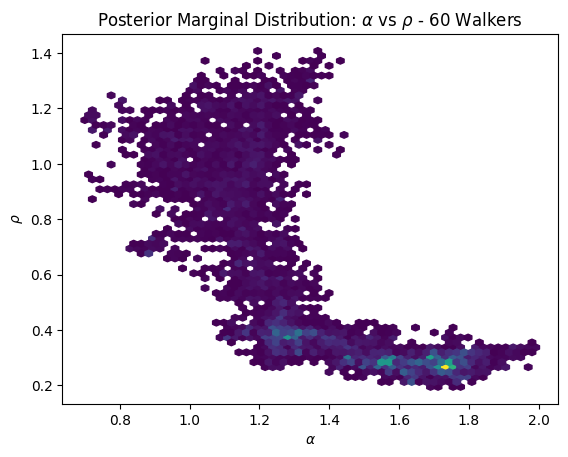

In [22]:
plt.hexbin(alpha, rho, gridsize=60, cmap='viridis', mincnt=1)
plt.title(r"Posterior Marginal Distribution: $\alpha$ vs $\rho$ - 60 Walkers")
plt.xlabel(r'$\alpha$')
plt.ylabel(r'$\rho$')